In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

from cart import DecisionTreeClassifier, DecisionTreeRegressor
from random_forest import RandomForestClassifier, RandomForestRegressor

CLASS_COLORS = ["b", "g", "y"]

iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [2]:
forest = RandomForestClassifier(n_estimators=100, max_depth=4, max_features=2, random_state=42)
forest.fit(X_train, y_train)

preds = forest.predict(X_test)
test_acc = accuracy_score(y_test, preds.ravel())

print(f"OOB score:      {forest.oob_score:.3f}")
print(f"Test accuracy:  {test_acc:.3f}")

OOB score:      0.964
Test accuracy:  0.921


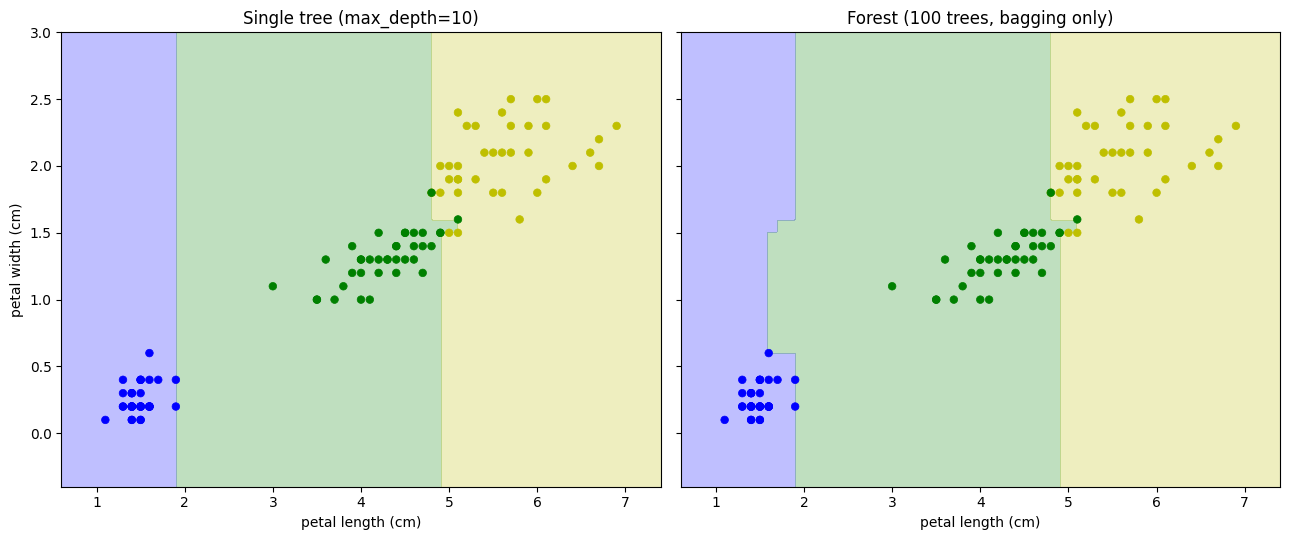

In [3]:
feat_x, feat_y = 2, 3  # petal length, petal width
X2_train = X_train[:, [feat_x, feat_y]]

single_tree = DecisionTreeClassifier(max_depth=10, min_samples_split=2, random_state=42)
single_tree.fit(X2_train, y_train)

forest_2d = RandomForestClassifier(n_estimators=100, max_depth=10, max_features=2, random_state=42)
forest_2d.fit(X2_train, y_train)

pad = 0.5
x_min, x_max = X2_train[:, 0].min() - pad, X2_train[:, 0].max() + pad
y_min, y_max = X2_train[:, 1].min() - pad, X2_train[:, 1].max() + pad
xv, yv = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.c_[xv.ravel(), yv.ravel()]

Z_tree = single_tree.predict(grid).reshape(xv.shape)
Z_forest = forest_2d.predict(grid).reshape(xv.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True, sharey=True)
for ax, Z, title in zip(axes, [Z_tree, Z_forest], ["Single tree (max_depth=10)", "Forest (100 trees, bagging only)"]):
    ax.contourf(xv, yv, Z, levels=[-0.5, 0.5, 1.5, 2.5], colors=CLASS_COLORS, alpha=0.25)
    ax.scatter(
        X2_train[:, 0], X2_train[:, 1],
        c=[CLASS_COLORS[c] for c in y_train],
        linewidth=0.5, s=30, zorder=3,
    )
    ax.set_title(title)
    ax.set_xlabel(iris.feature_names[feat_x])


axes[0].set_ylabel(iris.feature_names[feat_y])
plt.tight_layout()
plt.show()

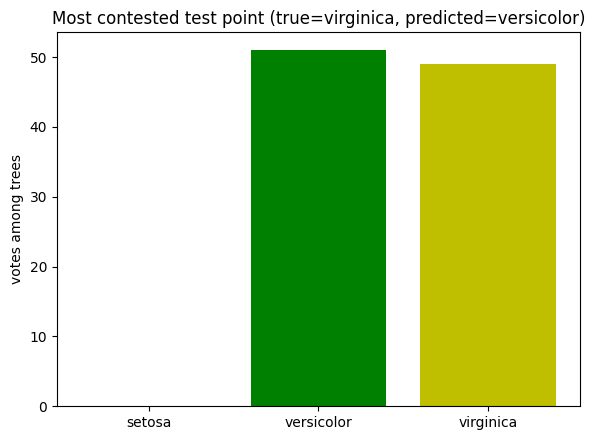

In [4]:
n_classes = len(np.unique(y_train))
vote_counts = np.zeros((X_test.shape[0], n_classes), dtype=int)
for tree in forest.trees:
    tree_preds = tree.predict(X_test)
    for i, p in enumerate(tree_preds):
        vote_counts[i, int(p)] += 1

# Most contested: smallest margin between the top two vote counts
sorted_counts = np.sort(vote_counts, axis=1)
margins = sorted_counts[:, -1] - sorted_counts[:, -2]
contested_idx = np.argmin(margins)

votes = vote_counts[contested_idx]
true_label = iris.target_names[y_test[contested_idx]]
predicted_label = iris.target_names[np.argmax(votes)]

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar(iris.target_names, votes, color=CLASS_COLORS, linewidth=0.5)
ax.set_ylabel("votes among trees")
ax.set_title(f"Most contested test point (true={true_label}, predicted={predicted_label})")

plt.tight_layout()
plt.show()

In [5]:
rng = np.random.default_rng(42)
X_reg = np.sort(rng.uniform(0, 10, 200)).reshape(-1, 1)
y_reg = np.sin(X_reg).ravel() + rng.normal(0, 0.15, X_reg.shape[0])

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=42
)

single_tree_reg = DecisionTreeRegressor(max_depth=4, min_samples_split=2, random_state=42)
single_tree_reg.fit(Xr_train, yr_train)

forest_reg = RandomForestRegressor(n_estimators=100, max_depth=4, min_samples_split=2,
                                    max_features=1, random_state=42)
forest_reg.fit(Xr_train, yr_train)

for name, model in [("single tree", single_tree_reg), ("forest", forest_reg)]:
    preds = model.predict(Xr_test)
    print(f"{name}: MSE={mean_squared_error(yr_test, preds):.3f}  R2={r2_score(yr_test, preds):.3f}")

print(f"forest OOB R2: {forest_reg.oob_score:.3f}")

single tree: MSE=0.042  R2=0.903
forest: MSE=0.047  R2=0.891
forest OOB R2: 0.902


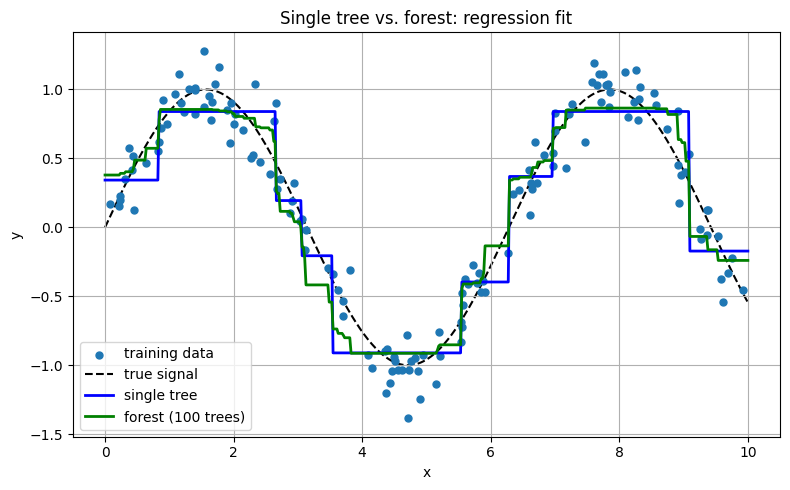

In [6]:
x_grid = np.linspace(0, 10, 500).reshape(-1, 1)
y_true = np.sin(x_grid).ravel()

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    Xr_train, yr_train,
    s=25, zorder=2, label="training data",
)
ax.plot(x_grid, y_true, color="k", linestyle="--", linewidth=1.5, label="true signal", zorder=1)
ax.plot(x_grid, single_tree_reg.predict(x_grid), color="b", linewidth=2, label="single tree", zorder=3)
ax.plot(x_grid, forest_reg.predict(x_grid), color="g", linewidth=2, label="forest (100 trees)", zorder=3)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Single tree vs. forest: regression fit")
ax.grid()
ax.legend()

plt.tight_layout()
plt.show()